In [ ]:
import pandas as pd
import numpy as np
import re
import pickle
import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [2]:
df = pd.read_csv("IMDB Dataset.csv", engine='python',
                 on_bad_lines='skip', encoding='utf8')

print("Shape:", df.shape)
print("\nClass distribution:")
print(df['sentiment'].value_counts())
df.head()

Shape: (50000, 2)

Class distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [10]:
stop_words  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

def preprocess(text):
    text   = re.sub(r'<.*?>', '', text)
    text   = text.lower()
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w.isalpha()]
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

df['clean_text'] = df['review'].apply(preprocess)
df['sentiment']  = df['sentiment'].map({'positive': 1, 'negative': 0})

print(df[['review', 'clean_text']].head(3))

                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   

                                          clean_text  
0  one reviewer mentioned watching oz episode hoo...  
1  wonderful little production filming technique ...  
2  thought wonderful way spend time hot summer we...  


In [4]:
vectorizer = TfidfVectorizer(
    max_features  = 50000,
    ngram_range   = (1, 2),
    sublinear_tf  = True,
    min_df        = 2,
    strip_accents = 'unicode'
)

X = vectorizer.fit_transform(df['clean_text'])
y = df['sentiment']

print("Feature matrix shape:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Feature matrix shape: (50000, 50000)
Train: 40000 | Test: 10000


In [5]:
models = {
    "Naive Bayes"         : MultinomialNB(alpha=0.1),
    "Logistic Regression" : LogisticRegression(C=10, max_iter=1000, solver='lbfgs', n_jobs=-1),
    "SVM"                 : LinearSVC(C=1.0, max_iter=2000),
    "Random Forest"       : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting"   : GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    print(f"Training {name}...", end=" ")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model"     : name,
        "Accuracy"  : round(accuracy_score(y_test, y_pred),  4),
        "Precision" : round(precision_score(y_test, y_pred), 4),
        "Recall"    : round(recall_score(y_test, y_pred),    4),
        "F1 Score"  : round(f1_score(y_test, y_pred),        4)
    })
    print(f"✅ Accuracy: {results[-1]['Accuracy']*100:.2f}%")

result_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
result_df

Training Naive Bayes... ✅ Accuracy: 88.45%
Training Logistic Regression... ✅ Accuracy: 90.59%
Training SVM... ✅ Accuracy: 90.35%
Training Random Forest... ✅ Accuracy: 86.78%
Training Gradient Boosting... ✅ Accuracy: 81.09%


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9059,0.8982,0.9156,0.9068
1,SVM,0.9035,0.8991,0.9090,0.9040
2,Naive Bayes,0.8845,0.8773,0.8940,0.8856
3,Random Forest,0.8678,0.8643,0.8726,0.8684
4,Gradient Boosting,0.8109,0.7788,0.8684,0.8212


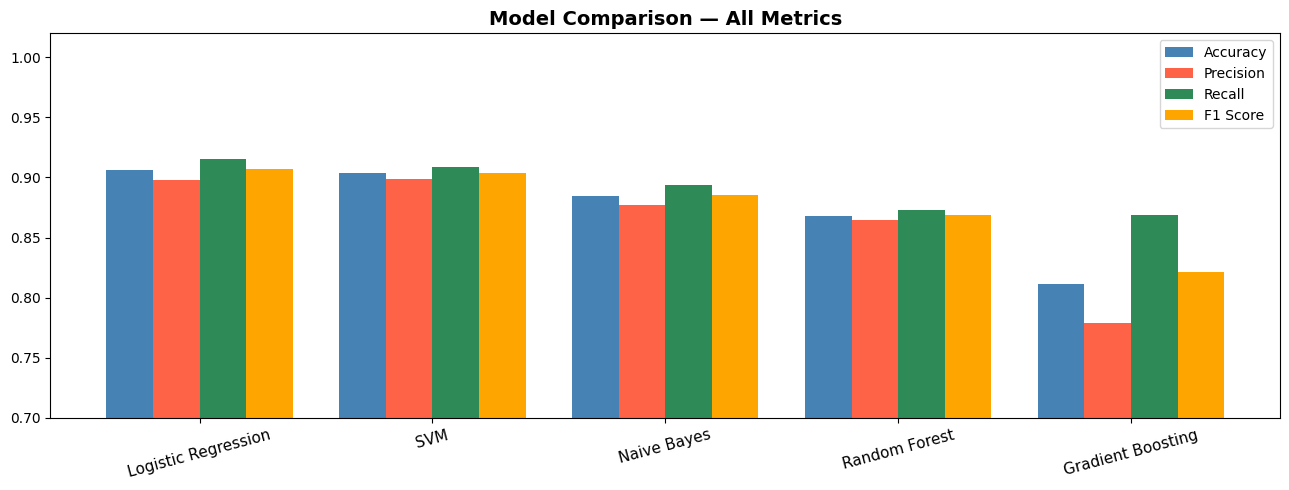

In [6]:
x     = range(len(result_df))
width = 0.2

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar([i-0.3 for i in x], result_df['Accuracy'],  width, label='Accuracy',  color='steelblue')
ax.bar([i-0.1 for i in x], result_df['Precision'], width, label='Precision', color='tomato')
ax.bar([i+0.1 for i in x], result_df['Recall'],    width, label='Recall',    color='seagreen')
ax.bar([i+0.3 for i in x], result_df['F1 Score'],  width, label='F1 Score',  color='orange')

ax.set_xticks(x)
ax.set_xticklabels(result_df['Model'], rotation=15, fontsize=11)
ax.set_ylim(0.7, 1.02)
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

Best Model  : Logistic Regression
Accuracy    : 90.59%
Precision   : 0.8982
Recall      : 0.9156
F1 Score    : 0.9068


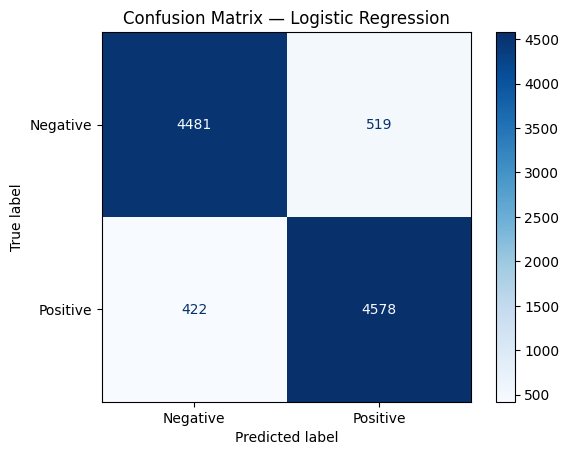

In [7]:
best_row   = result_df.iloc[0]
best_name  = best_row['Model']
best_model = models[best_name]

print(f"Best Model  : {best_name}")
print(f"Accuracy    : {best_row['Accuracy']*100:.2f}%")
print(f"Precision   : {best_row['Precision']}")
print(f"Recall      : {best_row['Recall']}")
print(f"F1 Score    : {best_row['F1 Score']}")

y_pred_best = best_model.predict(X_test)
cm   = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_name}')
plt.show()

In [8]:
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print(f"Saved best_model.pkl  ({best_name})")
print("Saved tfidf_vectorizer.pkl")

Saved best_model.pkl  (Logistic Regression)
Saved tfidf_vectorizer.pkl


In [9]:
!pip install gradio -q

import gradio as gr
import pickle

with open('best_model.pkl', 'rb') as f:
    gui_model = pickle.load(f)

with open('tfidf_vectorizer.pkl', 'rb') as f:
    gui_vec = pickle.load(f)

def predict_sentiment(review):
    cleaned    = preprocess(review)
    features   = gui_vec.transform([cleaned])
    prediction = gui_model.predict(features)[0]
    return "🟢 Positive" if prediction == 1 else "🔴 Negative"

demo = gr.Interface(
    fn          = predict_sentiment,
    inputs      = gr.Textbox(lines=5, placeholder="Paste a movie review here..."),
    outputs     = gr.Textbox(label="Predicted Sentiment"),
    title       = "🎬 Movie Review Sentiment Analyser",
    description = f"Best Model: {best_name} | Trained on IMDB 50K Dataset"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://34752a4a6b4c3de835.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
